# Chapter 29: Advanced Feature Selection

**Which columns does each screen keep, and at what null percentile does a strict screen start discarding real signal?**

Feature selection is a fitted procedure whose output is a smaller table. Knowing which columns it keeps, and what that costs on new rows, is the only way to tell a useful screen from an arbitrary one.

*Constructed data where the true role of every column is known; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Six constructed datasets of 700 rows with 25 columns whose roles are known: 3 continuous strong features, 4 weak binary features, and 18 columns that carry nothing (12 continuous, 4 binary, 2 integer ID-like with about 175 values). A random forest gives each column's impurity importance. The null is the same importance after shuffling the labels, repeated 12 times. A column is kept when its real importance exceeds its own null percentile (the control). The same number of columns is also chosen by raw importance rank, and all three tables (everything, null screen, raw top columns) are refitted and scored by AUC on 4,000 new rows.

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from kaggle_companion.activities._common import clean

SEED = 29
REPLICATES = 6          # independent constructed datasets; every estimate is their mean
PERMUTATIONS = 12       # label permutations that make the null importance of each feature
N_TRAIN, N_HELD = 700, 4000
# Column groups, in order: strong signal, weak signal (binary), noise, binary noise, ID-like noise.
GROUPS = [("strong", 3), ("weak", 4), ("noise", 12), ("binary_noise", 4), ("id_like", 2)]
KIND = np.array([name for name, count in GROUPS for _ in range(count)])
N_FEATURES = len(KIND)


def generate(n, rng):
    """Three continuous strong features, four weak binary features, and 18 columns that carry nothing:
    12 continuous, 4 binary and 2 integer ID-like columns with about n/4 distinct values."""
    strong = rng.normal(size=(n, 3))
    weak = (rng.random((n, 4)) < 0.5).astype(float)
    noise = rng.normal(size=(n, 12))
    binary_noise = (rng.random((n, 4)) < 0.5).astype(float)
    id_like = rng.integers(0, n // 4, (n, 2)).astype(float)
    logit = 0.9 * strong.sum(axis=1) + 0.7 * (weak.sum(axis=1) - 2)
    y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return np.column_stack([strong, weak, noise, binary_noise, id_like]), y


def forest(seed):
    return RandomForestClassifier(n_estimators=30, min_samples_leaf=3, max_features="sqrt", random_state=seed, n_jobs=1)


def importance(X, y, seed):
    """Impurity importance: the share of split gain each column earns. It is biased toward columns with many distinct values."""
    return forest(seed).fit(X, y).feature_importances_


def held_out_auc(columns, X, y, X_held, y_held, seed):
    model = forest(seed).fit(X[:, columns], y)
    return roc_auc_score(y_held, model.predict_proba(X_held[:, columns])[:, 1])


def one_replicate(percentile, seed):
    rng = np.random.default_rng(seed)
    X, y = generate(N_TRAIN, rng)
    X_held, y_held = generate(N_HELD, rng)
    real = importance(X, y, seed)
    # Null: refit after shuffling the labels, so every column's importance is what chance alone earns it.
    null = np.array([importance(X, rng.permutation(y), seed + 1 + i) for i in range(PERMUTATIONS)])
    threshold = np.percentile(null, percentile, axis=0)          # each column is compared with its own null
    kept = np.where(real > threshold)[0]
    raw_top = np.argsort(-real)[:len(kept)]                       # same number of columns, chosen by raw importance
    everything = np.arange(N_FEATURES)
    return {"real": real, "threshold": threshold, "kept": kept, "raw_top": raw_top,
            "auc_all": held_out_auc(everything, X, y, X_held, y_held, seed),
            "auc_null": held_out_auc(kept, X, y, X_held, y_held, seed) if len(kept) else 0.5,
            "auc_raw": held_out_auc(raw_top, X, y, X_held, y_held, seed) if len(kept) else 0.5}


def run(percentile):
    reps = [one_replicate(percentile, SEED * 100 + i) for i in range(REPLICATES)]
    count = lambda key, kind: float(np.mean([np.sum(KIND[r[key]] == kind) for r in reps]))
    first = reps[0]
    return clean({
        "percentile": percentile,
        "kept_null": {name: count("kept", name) for name, _ in GROUPS},
        "kept_raw": {name: count("raw_top", name) for name, _ in GROUPS},
        "columns_kept": float(np.mean([len(r["kept"]) for r in reps])),
        "auc_all": float(np.mean([r["auc_all"] for r in reps])),
        "auc_null": float(np.mean([r["auc_null"] for r in reps])),
        "auc_raw": float(np.mean([r["auc_raw"] for r in reps])),
        "per_replicate_auc": {k: [r["auc_" + k] for r in reps] for k in ("all", "null", "raw")},
        "first_dataset": {"kind": KIND.tolist(), "real": first["real"], "threshold": first["threshold"],
                          "kept": [int(i in first["kept"]) for i in range(N_FEATURES)]},
        "replicates": REPLICATES, "permutations": PERMUTATIONS, "columns": N_FEATURES, "training_rows": N_TRAIN,
    })


## Measure it across the control

The control is **null percentile a column's importance must exceed**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch29 import explain

VALUES = [50, 75, 90, 99]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                          50     75     90     99
Columns kept             7.0    5.8    5.5    5.2
Weak real kept (of 4)    3.3    2.7    2.3    2.0
Noise kept (of 18)       0.7    0.2    0.2    0.2
Null screen AUC        0.792  0.786  0.783  0.780
Raw top-k AUC          0.755  0.759  0.759  0.760
All columns AUC        0.767  0.767  0.767  0.767


## Look at it

The figure shows the default setting, null percentile a column's importance must exceed = 75.

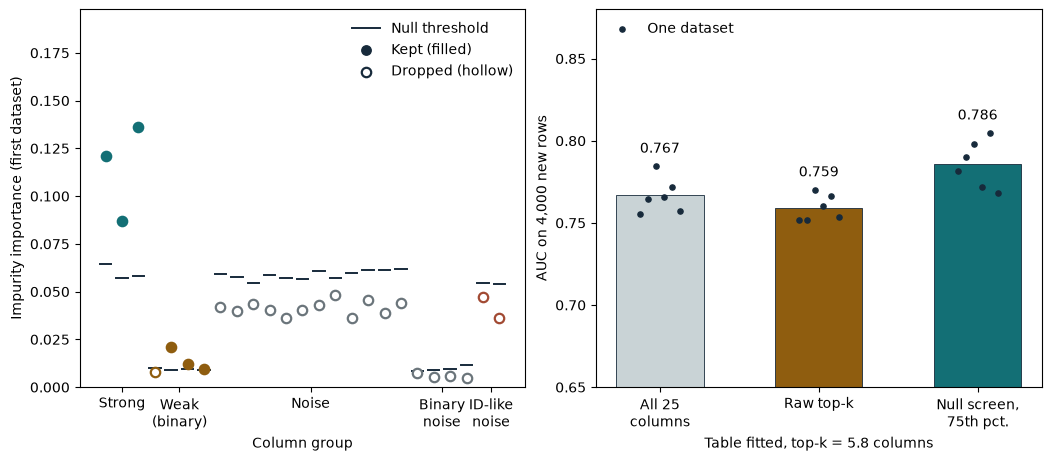

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch29 import draw, NCOLS, HEIGHT

DEFAULT = 75
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At the 75th null percentile the screen keeps 5.8 columns on average: 3.0 of 3 strong, 2.7 of 4 weak, 0.2 of 18 noise. The same number chosen by raw importance rank holds 3.0 of 3 strong, 0.0 of 4 weak, 2.8 of 18 noise. Scored on new rows the null screen reaches 0.786, the raw top columns 0.759 and the full table 0.767, so 0.786 - 0.767 = 0.019 is the change from screening with the null (negative means it cost AUC).

- Null screen: 0.786 - 0.767 = 0.019 AUC against keeping every column.
- Raw ranking of the same size: 0.759 - 0.767 = -0.008.
- Kept by the null screen: 3.0 of 3 strong, 2.7 of 4 weak, 0.2 of 18 noise.
- Kept by the raw ranking: 3.0 of 3 strong, 0.0 of 4 weak, 2.8 of 18 noise.

## Apply this to your competition

- Compute each feature's importance on the real labels and on shuffled labels, then compare a feature with its own null, not with other features.
- Do the whole screen inside development rows, with a permutation that respects groups or time if the data has them.
- Choose the percentile by held-out loss on matched folds and keep the same-size raw-rank selection as a baseline.
- Before removing a column, also test removing it with its correlated substitutes, and log each removal result.

Book location: Chapter 29, Null Importance: Distinguishing Real Signal from Chance Correlation.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)